# DADA2 backend: pure-Python ASV inference

The default `ov.alignment.amplicon_16s_pipeline` backend is **UNOISE3**
(via `vsearch`) — fast and benchmark-competitive. This notebook
demonstrates the **DADA2 backend**, powered by the pure-Python
[pydada2](https://github.com/omicverse/py-dada2) port (no R, no rpy2).

**Why a second backend?**  The canonical R DADA2 (Callahan *et al.* 2016)
is what much of the published 16S literature uses; reviewers sometimes
ask for its specific error-model-aware denoising even when UNOISE3
is equivalent on benchmarks. Having both lets users meet that
requirement without leaving Python.

**Install:**
```bash
pip install pydada2
```

**One-liner:**
```python
adata = ov.alignment.amplicon_16s_pipeline(
    fastq_dir='raw/',
    workdir='/scratch/.../run_dada2',
    backend='dada2',                      # ← switch backend
    db_fasta='/scratch/.../rdp_16s_v18.fa.gz',
)
```

## 1. Setup

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import omicverse as ov

ov.plot_set()

ROOT = Path('/scratch/users/steorra/analysis/omicverse_dev/cache/16s')
RAW  = ROOT / 'raw' / 'MiSeq_SOP'
DB   = '/scratch/users/steorra/analysis/omicverse_dev/db/rdp/rdp_16s_v18.fa.gz'
WORK = ROOT / 'run_dada2_tutorial'
WORK.mkdir(parents=True, exist_ok=True)

/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 2. Sample selection

DADA2 is about **2–4× slower** than UNOISE3 because of its position-aware
error model. For a tutorial we pick the first 6 mothur SOP samples (3
Early + 3 Late + Mock) — enough to show real group structure without a
half-hour runtime.

In [2]:
PICK = ['F3D0', 'F3D1', 'F3D2', 'F3D141', 'F3D142', 'F3D143', 'Mock']
samples = []
for name in PICK:
    fq1s = sorted(RAW.glob(f'{name}_S*_L001_R1_001.fastq'))
    if not fq1s:
        continue
    fq1 = fq1s[0]
    fq2 = RAW / fq1.name.replace('_R1_001', '_R2_001')
    samples.append((name, str(fq1), str(fq2)))
print('samples:', [s[0] for s in samples])

samples: ['F3D0', 'F3D1', 'F3D2', 'F3D141', 'F3D142', 'F3D143', 'Mock']


In [3]:
# sample metadata
rows = []
for name, _, _ in samples:
    if name.startswith('F3D'):
        day = int(re.findall(r'F3D(\d+)', name)[0])
        group = 'Early' if day <= 9 else 'Late'
    else:
        day, group = -1, 'Mock'
    rows.append({'sample': name, 'day': day, 'group': group})
meta = pd.DataFrame(rows).set_index('sample')
meta

        day  group
sample            
F3D0      0  Early
F3D1      1  Early
F3D2      2  Early
F3D141  141   Late
F3D142  142   Late
F3D143  143   Late
Mock     -1   Mock

## 3. Run the DADA2 backend

`amplicon_16s_pipeline(backend='dada2')` dispatches to
`ov.alignment.dada2_pipeline` after optional `cutadapt` trimming
(skipped here — mothur SOP ships pre-trimmed).

Under the hood:

1. `filter_and_trim` — quality trim each sample to 240/160 bp, max 2 expected errors
2. `learn_errors` — self-consistent error model fit on all F reads, then all R reads
3. `dada` (per sample) — divisive denoising on dereplicated reads
4. `merge_pairs` — merge paired-end reads using the denoiser output
5. `make_sequence_table` — sample × ASV-sequence table
6. `remove_bimera_denovo` — consensus chimera removal
7. Assemble AnnData + SINTAX taxonomy on the ASV FASTA

In [4]:
import time
t0 = time.time()
adata_dada2 = ov.alignment.amplicon_16s_pipeline(
    samples=samples,
    workdir=str(WORK),
    db_fasta=DB,
    backend='dada2',
    primer_fwd=None, primer_rev=None,   # mothur SOP is pre-trimmed
    filter_max_ee=2.0,
    sintax_cutoff=0.8,
    threads=4,
    sample_metadata=meta,
)
print(f't = {time.time()-t0:.1f}s  adata = {adata_dada2.shape}  reads = {int(adata_dada2.X.sum())}')

11068560 total bases in 46119 reads from 7 samples will be used for learning the error rates.


   selfConsist round 1: re-estimated error rates.


   selfConsist round 2: re-estimated error rates.


   selfConsist round 3: re-estimated error rates.


   selfConsist round 4: re-estimated error rates.


...

   selfConsist round 2: re-estimated error rates.


   selfConsist round 3: re-estimated error rates.


   selfConsist converged after 4 round(s).


>> /home/users/steorra/miniforge3/envs/omicverse/bin/vsearch --sintax /scratch/users/steorra/analysis/omicverse_dev/cache/16s/run_dada2_tutorial/asv/asvs.fasta --db /scratch/users/steorra/analysis/omicverse_dev/db/rdp/rdp_16s_v18.fa.gz --tabbedout /scratch/users/steorra/analysis/omicverse_dev/cache/16s/run_dada2_tutorial/taxonomy/sintax.tsv --sintax_cutoff 0.8 --strand both --threads 4


t = 745.0s  adata = (7, 192)  reads = 42533


In [5]:
adata_dada2.var[['phylum','class','genus','sintax_confidence']].head(10)

              phylum        class        genus  sintax_confidence
asv                                                              
ASV1   Bacteroidetes  Bacteroidia  Duncaniella               1.00
ASV2   Bacteroidetes  Bacteroidia  Duncaniella               0.99
ASV3   Bacteroidetes  Bacteroidia                            0.79
ASV4   Bacteroidetes  Bacteroidia    Alistipes               1.00
ASV5   Bacteroidetes  Bacteroidia                            0.48
ASV6   Bacteroidetes  Bacteroidia                            0.42
ASV7   Bacteroidetes  Bacteroidia                            0.56
ASV8   Bacteroidetes  Bacteroidia  Bacteroides               1.00
ASV9   Bacteroidetes  Bacteroidia                            0.77
ASV10  Bacteroidetes  Bacteroidia                            0.36

## 4. Downstream (reuses `ov.micro`)

The DADA2 pipeline returns the **same AnnData schema** as the UNOISE3
backend, so every `ov.micro` helper works without modification.

In [6]:
# alpha diversity
min_depth = int(np.asarray(adata_dada2.X.sum(axis=1)).min())
ov.micro.Alpha(adata_dada2, rarefy_depth=min_depth).run(['shannon', 'observed_otus'])

# beta + PCoA
ov.micro.Beta(adata_dada2, rarefy_depth=min_depth).run(metric='braycurtis')
ov.micro.Ordinate(adata_dada2, dist_key='braycurtis').pcoa(n=3)

adata_dada2.obs[['day','group','shannon','observed_otus']]

/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/skbio/util/_warning.py:40: DeprecationWarning: `observed_otus` was renamed to `sobs` in 0.6.0. The old name is kept as an alias but is deprecated.
  warn(message, warning)


        day  group   shannon  observed_otus
sample                                     
F3D0      0  Early  3.860640            106
F3D1      1  Early  3.961006             99
F3D2      2  Early  3.576407            123
F3D141  141   Late  3.404435             73
F3D142  142   Late  3.143007             49
F3D143  143   Late  3.243364             52
Mock     -1   Mock  2.790998             20

/tmp/ipykernel_14448/2983288971.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=groups, patch_artist=True, widths=0.5, showfliers=False)
/tmp/ipykernel_14448/2983288971.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=groups, patch_artist=True, widths=0.5, showfliers=False)


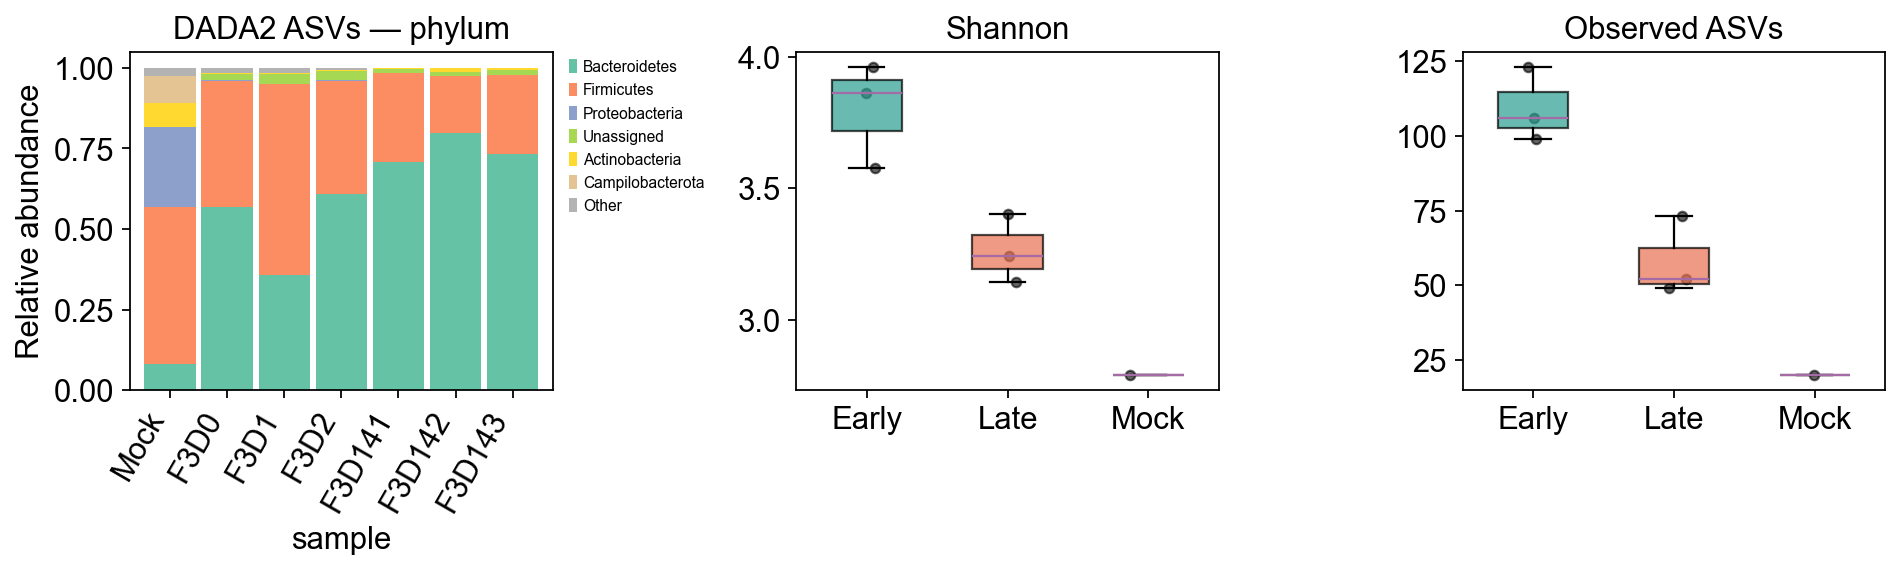

In [7]:
palette = {'Early': '#2a9d8f', 'Late': '#e76f51', 'Mock': '#264653'}
groups = ['Early', 'Late', 'Mock']

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
# 1. phylum-level taxonomy stacked bar
from scipy import sparse as _sp
X = adata_dada2.X.toarray() if _sp.issparse(adata_dada2.X) else np.asarray(adata_dada2.X)
phy = adata_dada2.var['phylum'].replace('', 'Unassigned').values
pdf = pd.DataFrame(X, index=adata_dada2.obs_names, columns=phy).T.groupby(level=0).sum().T
pdf = pdf.div(pdf.sum(axis=1), axis=0).fillna(0)
order = adata_dada2.obs.sort_values('day').index
top = pdf.sum().sort_values(ascending=False).head(6).index.tolist()
pplot = pdf[top].loc[order].copy()
pplot['Other'] = 1 - pplot.sum(axis=1)
pplot.plot(kind='bar', stacked=True, ax=axes[0], width=0.9,
           color=plt.cm.Set2(np.linspace(0,1,len(pplot.columns))))
axes[0].set_title('DADA2 ASVs — phylum')
axes[0].set_ylabel('Relative abundance')
axes[0].legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=7)
plt.setp(axes[0].get_xticklabels(), rotation=60, ha='right')

# 2. Shannon + Observed boxes
for ax, metric, ylabel in zip(axes[1:], ['shannon', 'observed_otus'],
                              ['Shannon', 'Observed ASVs']):
    data = [adata_dada2.obs[adata_dada2.obs.group==g][metric].dropna().values for g in groups]
    bp = ax.boxplot(data, labels=groups, patch_artist=True, widths=0.5, showfliers=False)
    for patch, g in zip(bp['boxes'], groups):
        patch.set_facecolor(palette[g]); patch.set_alpha(0.7)
    for i, (g, vals) in enumerate(zip(groups, data), start=1):
        x = np.random.normal(i, 0.05, size=len(vals))
        ax.scatter(x, vals, color='k', alpha=0.6, s=18)
    ax.set_title(ylabel)
plt.tight_layout()
plt.show()

## 5. PCoA on DADA2 ASVs

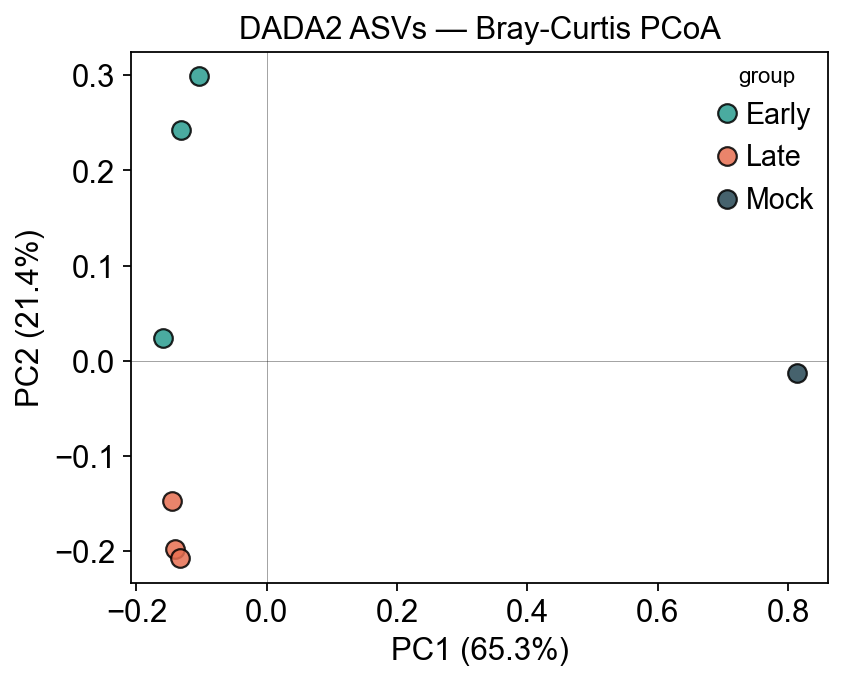

In [8]:
coords = pd.DataFrame(adata_dada2.obsm['braycurtis_pcoa'],
                      index=adata_dada2.obs_names, columns=['PC1','PC2','PC3'])
pct = adata_dada2.uns['micro']['braycurtis_pcoa_var'] * 100

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for g in groups:
    sub = adata_dada2.obs[adata_dada2.obs.group == g]
    if sub.empty: continue
    ax.scatter(coords.loc[sub.index, 'PC1'],
               coords.loc[sub.index, 'PC2'],
               color=palette[g], s=70, alpha=0.85, edgecolor='k', label=g)
ax.set_xlabel(f'PC1 ({pct[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({pct[1]:.1f}%)')
ax.set_title('DADA2 ASVs — Bray-Curtis PCoA')
ax.legend(title='group')
ax.axhline(0, color='k', lw=0.4, alpha=0.4)
ax.axvline(0, color='k', lw=0.4, alpha=0.4)
plt.tight_layout()
plt.show()

## Notes

- **When to pick DADA2 over UNOISE3?** If a journal / reviewer explicitly
  requires DADA2-style error-model denoising for reproducibility with
  the original paper's pipeline. On benchmarks (Vestergaard 2024 ISME
  Comms) UNOISE3 ≈ DADA2 for biological signal recovery, with UNOISE3
  ~3× faster.
- **Performance.** `pydada2.dada` is ~1–2× slower than the R/C++ DADA2
  (pure Python, no Cython yet). Acceptable for <200 samples.
- **Taxonomy.** This tutorial reuses the SINTAX reference we already
  built for the UNOISE3 tutorial — the DADA2 ASV FASTA is piped through
  `ov.alignment.vsearch.sintax`. For DADA2-native RDP naive Bayes, use
  `pydada2.assign_taxonomy` with a DADA2-formatted training set (e.g.
  `silva_nr99_v138.1_wSpecies_train_set.fa.gz`).